# Full Process Lens For This Project

Use this section every time you start a project so you practice the same end-to-end workflow, not just isolated coding tasks.

## 1) Data Transformation and Processing (What and Why)

Raw data is rarely model-ready. Your first job is to transform data into a reliable, learnable format.

What to do in every project:
- Identify data types and expected schema.
- Handle missing values, duplicates, and inconsistent formats.
- Convert features into model-usable representations (encoding, scaling, tokenization, chunking, etc.).
- Keep transformations reproducible so train and inference use the same logic.
- Document assumptions and risks introduced by preprocessing choices.

Why this matters:
- Better preprocessing usually improves results more than switching algorithms.
- Poor preprocessing creates hidden errors that look like model failure.

## 2) Evaluating and Improving Models (What and Why)

Evaluation is not the last step. It is the loop that drives improvement.

What to do in every project:
- Start with a baseline and compare against it.
- Choose metrics tied to the real goal (not just convenience metrics).
- Inspect errors by slice (segments, classes, edge cases).
- Tune thresholds, features, prompts, retrieval settings, or hyperparameters based on evidence.
- Re-evaluate after each change and keep track of what improved and what regressed.

Why this matters:
- A model can appear good overall but fail on important cases.
- Iterative evaluation is how projects become production-ready, not just demo-ready.

## 3) Project Reflection Checklist

Before marking this project complete, confirm:
- I can explain how data was transformed and why.
- I can explain which metrics I chose and why.
- I can show at least one improvement cycle from evaluation findings.
- I can describe current limitations and next improvements.

In [201]:
# First run check (beginner safe)
import sys
import numpy as np
import pandas as pd

np.random.seed(42)  # Set a fixed random seed for reproducibility
print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)
print('Setup check passed. You can continue.')

Python version: 3.9.6
NumPy version: 2.0.2
pandas version: 2.3.3
Setup check passed. You can continue.


# Beginner Start Here (Weeks 4-5: Churn Predictor)

You are not expected to know machine learning yet. This notebook teaches while you build.

## What is churn?
Churn means a customer stops using a product or service.

## What is the goal?
Predict whether a customer will churn (`1`) or stay (`0`).

## Modules used in this notebook
- `pandas`: table data (`DataFrame`) and CSV loading.
- `numpy`: math and arrays.
- `sklearn`: machine learning models and evaluation tools.
- `matplotlib`/`seaborn`: charts and visual analysis.

## Key terms
- Feature: an input column (for example `tenure`, `monthly_charges`).
- Target/Label: what we are trying to predict (`churn`).
- Train/Test split: train on one part of data, evaluate on unseen part.
- Accuracy/Precision/Recall/F1: performance metrics.
- Confusion matrix: table of correct/incorrect predictions.

## How to work through this notebook
1. Run cells from top to bottom.
2. Read markdown before coding.
3. If an error appears, read the last line first.
4. Change one thing at a time and re-run.

# Weeks 4-5: Customer Churn Predictor

## Overview
Build a complete ML pipeline to predict which customers will churn (leave).

**Learning Goals:**
- Full ML pipeline (data → model → evaluation)
- Classification (predicting categories)
- Model comparison
- Business interpretation

**Time:** 8-12 hours across 2 weeks

**Difficulty:** 🟡 Combine foundations + new concepts

---

## Challenge Summary
12 challenges total, completing a full ML project from data preparation to business insights.

## Challenge 1: Load and Explore Data

**Goal:** Load a customer churn dataset and understand its structure.

**Steps:**
1. Import pandas, numpy, matplotlib, seaborn
2. Load dataset (create synthetic or download from Kaggle)
3. Display shape, columns, data types
4. Show first 5 rows
5. Get basic info about the dataset

**Expected outputs:**
- Dataset shape: 5000+ rows × 10-20 columns
- Target column: 'Churn' (yes/no or 1/0)
- Features: customer demographics, usage, billing info

In [202]:
# Challenge 1: Load and Explore Data

# YOUR CODE HERE
df=pd.read_csv("../../../data/phase1/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [204]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [205]:
df.shape

(7043, 21)

In [206]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [207]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Challenge 2: Data Quality Check

**Goal:** Understand data completeness and identify issues.

**Steps:**
1. Check for missing values per column
2. Show data types
3. Get summary statistics
4. Check target variable distribution (class balance)
5. Identify any obvious issues

**Expected outputs:**
- Missing values count (hopefully < 5%)
- Data types: mix of numeric and categorical
- Churn class distribution (% churned vs retained)

In [208]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [209]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [210]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [211]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [212]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [213]:
total_churned=len(df[df['Churn'] == "Yes"])
total_retained=len(df[df['Churn'] == "No"])
print(f"Total Churned: {total_churned}")
print(f"Total Retained: {total_retained}")

Total Churned: 1869
Total Retained: 5174


In [214]:
percent_churned = (total_churned / (total_churned + total_retained)) * 100
print(f"Percentage Churned: {percent_churned:.2f}%")

percent_retained = (total_retained / (total_churned + total_retained)) * 100
print(f"Percentage Retained: {percent_retained:.2f}%")

Percentage Churned: 26.54%
Percentage Retained: 73.46%


## Pre-Training Learning Checkpoint (Before Visualization)

Complete this teaching checkpoint before starting visualization and model training.

Use Phase 0 as your reference:
- guides/phase0/GUIDE_Week2_PandasDeep.md
- guides/phase0/GUIDE_Week3_NumPyDeep.md
- guides/phase0/GUIDE_Week4_Visualization.md
- docs/AI-ML-LEARNING-GUIDE.md (Phase 0 and Phase 1 sections)

Questions to answer in markdown before moving on:
1. What data quality issues exist (missing values, wrong types, duplicates, outliers)?
2. What needs to be transformed before training, and why?
3. Is the target variable clearly defined and consistently encoded?
4. What preprocessing choices could change model behavior?
5. What baseline will you compare against after training?

Done criteria:
- You can explain your data fixing and preparation plan in plain language.
- You can justify preprocessing decisions before training begins.
- You are ready to visualize with a clean data strategy.

### checking types to get ready for ML

In [215]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

##### find all null and na values

In [216]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [217]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### convert charges to numeric

In [218]:
df["MonthlyCharges"]=pd.to_numeric(df["MonthlyCharges"], errors='coerce')
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"], errors='coerce')

df["MonthlyCharges"].dtype, df["TotalCharges"].dtype

(dtype('float64'), dtype('float64'))

#### use loop to extract all none numbers from data frame, and change the,m to categpries because they are repeated

In [219]:

for col in df.columns:
    if df[col].dtype == 'object' and col != 'customerID':
        df[col] = df[col].astype('category')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [220]:
df.dtypes

customerID            object
gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

## Challenge 3: Visualize Relationships

**Goal:** Understand which features relate to churn.

**Steps:**
1. Create 3-4 visualizations showing:
   - Feature distributions
   - How features differ between churned/retained customers
   - Relationships with churn target
2. Examples: scatter plots, box plots, histograms
3. Label axes clearly

**Expected insights:**
- Some features are clearly different for churned customers
- Patterns visible in the data

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns


In [222]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


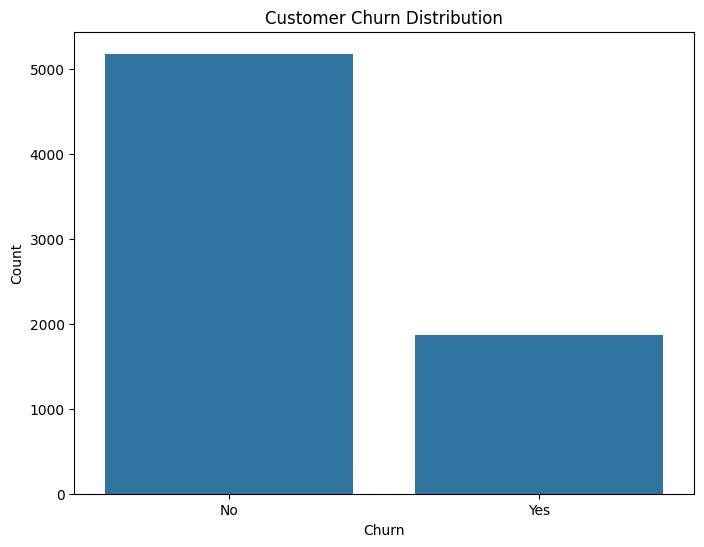

In [223]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.countplot(x='Churn', data=df, ax=axes)
axes.set_title('Customer Churn Distribution')
axes.set_xlabel('Churn')
axes.set_ylabel('Count')
plt.show()

In [224]:
df.dtypes

customerID            object
gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

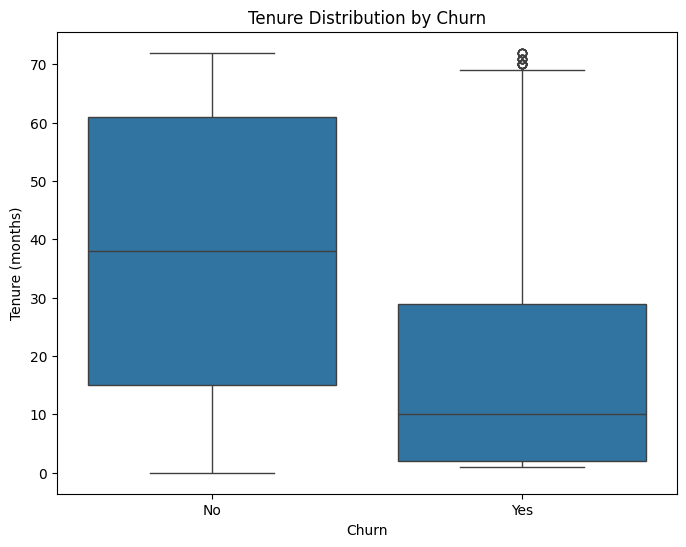

In [225]:
fig,ax= plt.subplots(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Tenure (months)')
plt.show()

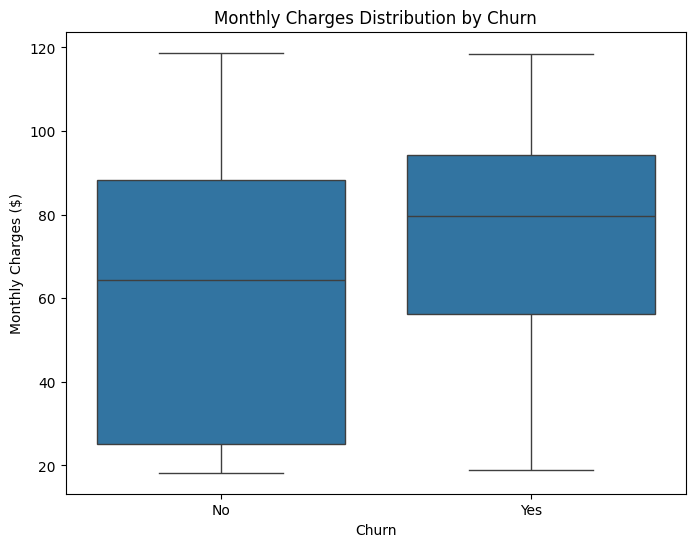

In [226]:
fig,ax= plt.subplots(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
ax.set_title('Monthly Charges Distribution by Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.show()

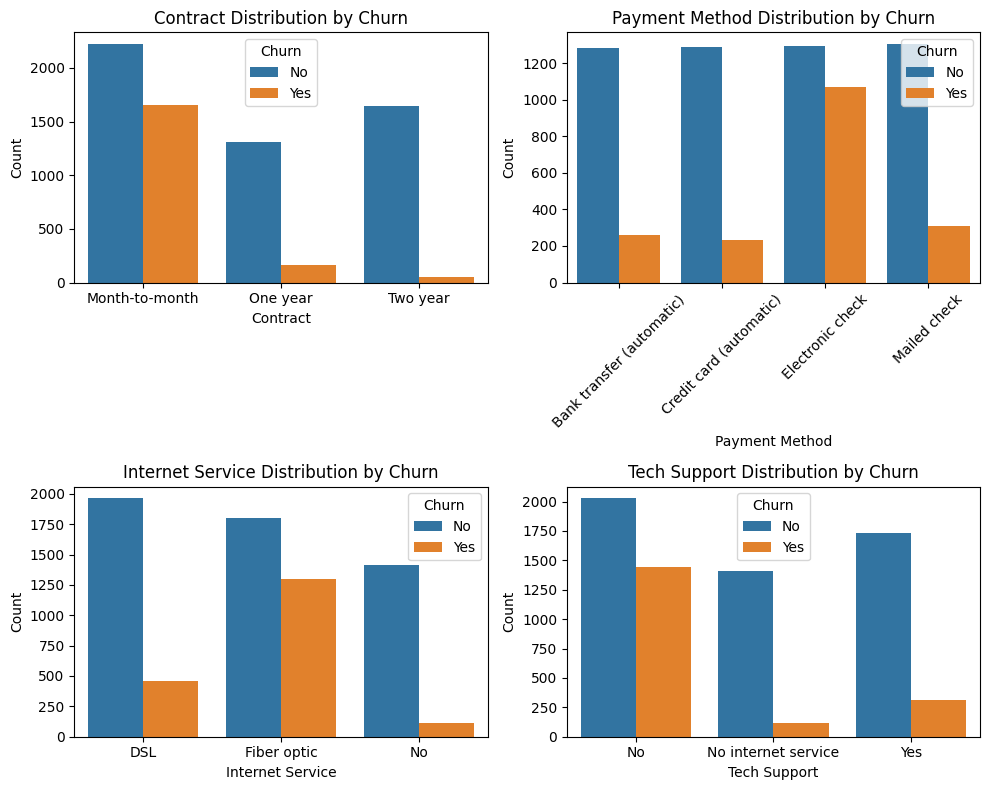

In [227]:
fig, ax = plt.subplots(2,2,figsize = (10, 8))

ax1 = ax[0, 0]
ax2 = ax[0, 1]
ax3 = ax[1, 0]
ax4 = ax[1, 1]

sns.countplot(x='Contract', hue='Churn', data=df, ax=ax1)
ax1.set_title('Contract Distribution by Churn')
ax1.set_xlabel('Contract')
ax1.set_ylabel('Count')


sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=ax2)
ax2.set_title('Payment Method Distribution by Churn')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

sns.countplot(x='InternetService', hue='Churn', data=df, ax=ax3)
ax3.set_title('Internet Service Distribution by Churn')
ax3.set_xlabel('Internet Service')
ax3.set_ylabel('Count')

sns.countplot(x='TechSupport', hue='Churn', data=df, ax=ax4)
ax4.set_title('Tech Support Distribution by Churn')
ax4.set_xlabel('Tech Support')
ax4.set_ylabel('Count')

plt.tight_layout()


plt.show()

### Observations
    -Customers in log term contracts are less likely to churn
        month-to-month customers churn at an extreme rate, chich mean customers in longterm commitment churn way less

    -Customers using digital payments are less likely to churn
        Customers using bank transfers and card payments which are both automatic are less likely to churn, makes me wonder if some forgets about the services

    - Customers with no tech support are more likely to churn. 
        no tech suppport could lead to errors and problems that could lead to customers churning 

    -Customers with Fiber optic have a near 60/40 chance of churning

## Challenge 4: Data Preparation

**Goal:** Prepare data for model training.

**Steps:**
1. Separate features (X) from target (y)
2. Handle missing values (drop or impute)
3. Encode categorical variables (one-hot encoding)
4. Scale numerical features (StandardScaler)
5. Split into train/test (80/20):
   - Train: fit scaler, train model
   - Test: evaluate performance

**Expected outputs:**
- X_train shape: (n, m) where n is ~80% of data
- X_test shape: (n, m) where n is ~20% of data
- Scaled features (mean ~0, std ~1)

In [228]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


### checking for nuls, and nas

In [229]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### droping missing since only 11 rows

In [230]:
df.dropna(inplace=True)
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [231]:
df.drop(columns=['customerID'], inplace=True)
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


### split for training and testing

In [232]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['Churn'])
y=df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

### we need to convert and fix nun numeric colums

In [233]:
x.dtypes

gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
dtype: object

In [234]:
numeric_cols=[]
categorical_cols=[]

for col in x.columns:
    if df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    elif df[col].dtype == 'category':
        categorical_cols.append(col)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


***encode catergories, and scale numerics***

In [235]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

***apply the transformations to the training and testing data***

In [236]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((5625, 45), (1407, 45))

## Challenge 5: Train Two Models

**Goal:** Build two competing classification models.

**Steps:**
1. Import LogisticRegression and RandomForestClassifier
2. Train model1 = LogisticRegression(random_state=42)
3. Train model2 = RandomForestClassifier(n_estimators=100, random_state=42)
4. Time each training
5. Make predictions on test set

**Expected:**
- Both models trained successfully
- Predictions are 0 or 1 (binary)
- Random Forest likely slower but potentially more accurate

In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


##### Training both models

In [238]:
model1=LogisticRegression(random_state=42,max_iter=1000)

model1.fit(X_train_processed, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [239]:
model2=RandomForestClassifier(random_state=42,n_estimators=100)

model2.fit(X_train_processed, y_train)



RandomForestClassifier(random_state=42)

***the random forest took more time to train because its more complex and usually more accurate***

## Challenge 6: Make Predictions

**Goal:** Generate predictions from both models.

**Steps:**
1. Get class predictions: model.predict(X_test)
2. Get probability predictions: model.predict_proba(X_test)
3. For each model, show:
   - First 10 predictions
   - Corresponding probabilities
   - Actual values
4. Compare predictions between models

**Expected:**
- predictions: array of 0s and 1s
- probabilities: array of values 0.0-1.0
- Some predictions might agree, some differ

### Lets Make Predictions with both model

In [240]:

lr_model_preds=model1.predict(X_test_processed)
lr_model_preds[:10]

array(['No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No'],
      dtype=object)

In [241]:

rf_model_preds=model2.predict(X_test_processed)
rf_model_preds[:10]

array(['No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No'],
      dtype=object)

In [242]:
y_prob_lr = model1.predict_proba(X_test_processed)
y_prob_lr[:10]

array([[0.98248697, 0.01751303],
       [0.40807869, 0.59192131],
       [0.99517897, 0.00482103],
       [0.79834833, 0.20165167],
       [0.8984986 , 0.1015014 ],
       [0.5281551 , 0.4718449 ],
       [0.97348188, 0.02651812],
       [0.83456899, 0.16543101],
       [0.32040045, 0.67959955],
       [0.98447537, 0.01552463]])

In [243]:
y_prob_rf = model2.predict_proba(X_test_processed)
y_prob_rf[:10]

array([[0.98      , 0.02      ],
       [0.19      , 0.81      ],
       [0.99      , 0.01      ],
       [0.94333333, 0.05666667],
       [0.86      , 0.14      ],
       [0.65      , 0.35      ],
       [0.98      , 0.02      ],
       [0.73      , 0.27      ],
       [0.31      , 0.69      ],
       [0.99      , 0.01      ]])

### the prediction are identical for the first 10, but base on propability the accuracy of model 2 is higher

## Challenge 7: Evaluate Models

**Goal:** Calculate performance metrics for both models.

**Steps:**
1. Import: accuracy_score, precision_score, recall_score, f1_score
2. For each model, calculate:
   - Accuracy: % correct predictions
   - Precision: % predicted churners who actually churned
   - Recall: % actual churners we caught
   - F1: balance between precision & recall
3. Create comparison table
4. Identify which model performs better

**Expected:**
- All metrics 0.0-1.0
- Usually Random Forest > Logistic Regression
- Metrics might differ (one model good at precision, other at recall)

In [244]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [245]:
lr_accuracy=accuracy_score(y_test, lr_model_preds)
lr_precision=precision_score(y_test, lr_model_preds, pos_label='Yes')
lr_recall=recall_score(y_test, lr_model_preds, pos_label='Yes')
lr_f1=f1_score(y_test, lr_model_preds, pos_label='Yes')

print(f"Logistic Regression - Accuracy: {lr_accuracy:.4f}, Precision: {lr_precision:.4f}, Recall: {lr_recall:.4f}, F1 Score: {lr_f1:.4f}")

Logistic Regression - Accuracy: 0.8038, Precision: 0.6485, Recall: 0.5722, F1 Score: 0.6080


In [246]:
rf_accuracy=accuracy_score(y_test, rf_model_preds)
rf_precision=precision_score(y_test, rf_model_preds, pos_label='Yes')
rf_recall=recall_score(y_test, rf_model_preds, pos_label='Yes')
rf_f1=f1_score(y_test, rf_model_preds, pos_label='Yes')

print(f"Random Forest - Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}, F1 Score: {rf_f1:.4f}")

Random Forest - Accuracy: 0.7832, Precision: 0.6194, Recall: 0.4786, F1 Score: 0.5400


In [247]:
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1 Score': [lr_f1, rf_f1]
})
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Random Forest,0.783227,0.619377,0.478610,0.539970


### suprissingly the logistic regresion model over performe the random forest

## Challenge 8: Confusion Matrix

**Goal:** Understand prediction patterns using confusion matrix.

**Steps:**
1. Import confusion_matrix, classification_report
2. Calculate confusion matrix for best model
3. Visualize as heatmap (seaborn)
4. Interpret:
   - True Negatives (top-left)
   - False Positives (top-right)
   - False Negatives (bottom-left)
   - True Positives (bottom-right)
5. Print classification report

**Expected insight:**
- Model predicts most customer correctly
- Some false positives/negatives are expected

In [248]:
from sklearn.metrics import confusion_matrix, classification_report

lr_cm=confusion_matrix(y_test, lr_model_preds)
print("Logistic Regression Confusion Matrix:",lr_cm)

Logistic Regression Confusion Matrix: [[917 116]
 [160 214]]


<Axes: >

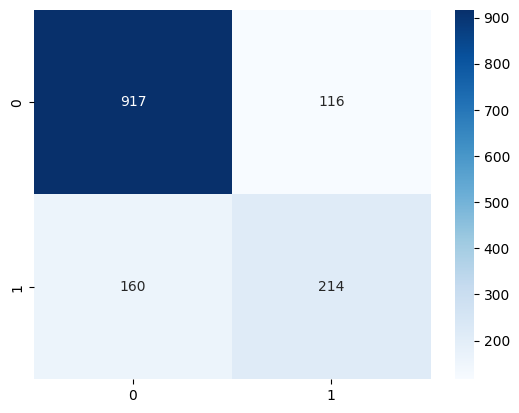

In [249]:
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')

In [250]:
lr_cr=classification_report(y_test, lr_model_preds)
print("Logistic Regression Classification Report:\n", lr_cr)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### metrics finding

* The model correctly identifies most non-churn customers (917 true negatives), showing strong performance for retention prediction.
* However, it misses 160 actual churners, indicating a limitation in detecting at-risk customers.
* The model correctly identifies 214 churners, but recall (57%) shows that a significant portion of churners are still being missed.
* There are 116 false positives, meaning some customers are incorrectly flagged as churn risks.

## Challenge 9: Feature Importance

**Goal:** Identify which features drive churn predictions.

**Steps:**
1. Extract feature_importances_ from Random Forest
2. Create dataframe with feature names and importances
3. Sort by importance descending
4. Plot top 10 features as horizontal bar chart
5. Print insights: what drives customers to churn?

**Expected:**
- Top features are clearly identified
- Bar chart shows relative importance
- Business insights (e.g., "contract length matters most")

In [251]:
rf_feature_importances=model2.feature_importances_
rf_feature_importances

array([0.02019606, 0.14272059, 0.13279712, 0.1609464 , 0.01836703,
       0.01890798, 0.01398875, 0.01419797, 0.01275512, 0.01237224,
       0.00289227, 0.00304953, 0.01275716, 0.00269822, 0.01391416,
       0.01054923, 0.02985554, 0.00304691, 0.03231258, 0.00225618,
       0.01110732, 0.01827646, 0.00064027, 0.0129136 , 0.01475004,
       0.00288429, 0.0117305 , 0.02275196, 0.00298281, 0.01174635,
       0.01148816, 0.00249178, 0.01190246, 0.01119483, 0.00495474,
       0.01149243, 0.04972451, 0.01087062, 0.01837682, 0.0151717 ,
       0.01527819, 0.01162054, 0.01247154, 0.03184133, 0.01075568])

In [252]:
feature_names=preprocessor.get_feature_names_out()
feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__

In [253]:
importance_df=pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importances
    })
importance_df.head(2)

,Feature,Importance
0,num__SeniorCitizen,0.020196
1,num__tenure,0.142721


In [254]:
importance_df.sort_values(by='Importance', ascending=False, inplace=True)
importance_df.head(10)

,Feature,Importance
3,num__TotalCharges,0.160946
1,num__tenure,0.142721
2,num__MonthlyCharges,0.132797
36,cat__Contract_Month-to-month,0.049725
18,cat__OnlineSecurity_No,0.032313
43,cat__PaymentMethod_Electronic check,0.031841
16,cat__InternetService_Fiber optic,0.029856
27,cat__TechSupport_No,0.022752
0,num__SeniorCitizen,0.020196
5,cat__gender_Male,0.018908


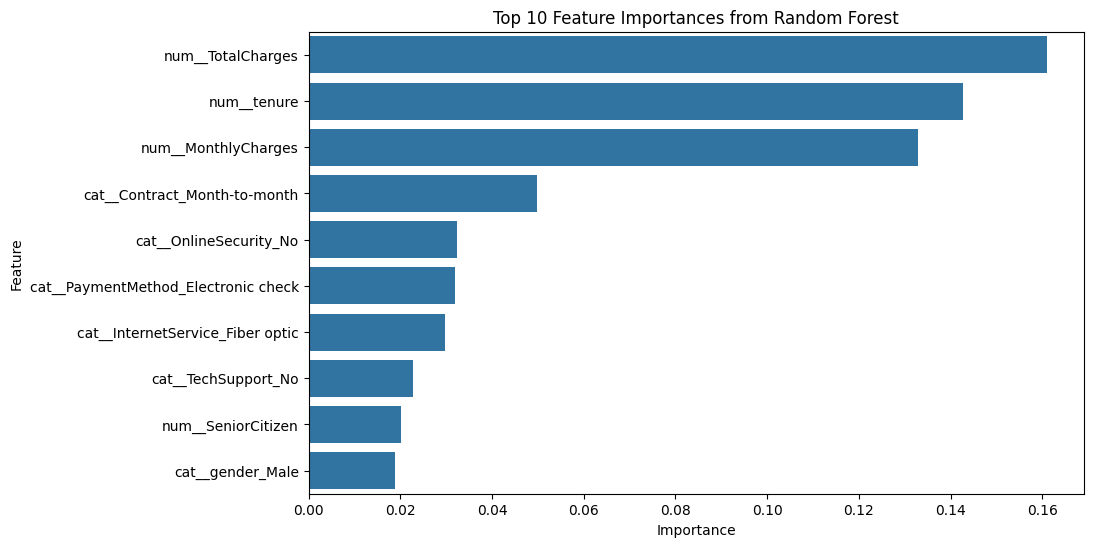

In [255]:
fig,ax=plt.subplots(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), ax=ax)
ax.set_title('Top 10 Feature Importances from Random Forest')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.show()

#### Churn is driven by:
- lack of commitment (contract)
- lack of support/services
- high cost
- early customer lifecycle

## Challenge 10: Prediction Function

**Goal:** Create reusable function for new predictions.

**Steps:**
1. Create function: predict_churn(customer_data)
2. Function should:
   - Take raw customer features as input
   - Apply same preprocessing (scaling/encoding)
   - Make prediction with best model
   - Return: prediction + probability
3. Test on 3 examples
4. Verify it works correctly

**Expected:**
- Function runs without errors
- Returns prediction (0 or 1) + probability
- Produces reasonable outputs

In [256]:
def predict_churn(customer_data):
    """
    Predicts whether a customer will churn based on their data.
    
    Parameters:
    customer_data (dict): A dictionary containing the customer's features.
    
    Returns:
    str: 'Yes' if the customer is predicted to churn, 'No' otherwise. + float: Probability of churning.
    """
    # Convert input data to DataFrame
    input_df = pd.DataFrame([customer_data])
    
    # Preprocess the input data
    input_processed = preprocessor.transform(input_df)
    
    # Make prediction using the trained model (using Random Forest here)
    prediction = model1.predict(input_processed)
    probability = model1.predict_proba(input_processed)
    
    return prediction[0], probability[0][1]  # Return predicted class and probability of churning


In [257]:
test_customers = [
    {
        'gender': 'Female',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'No',
        'tenure': 1,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 95.0,
        'TotalCharges': 95.0
    },
    {
        'gender': 'Male',
        'SeniorCitizen': 0,
        'Partner': 'Yes',
        'Dependents': 'Yes',
        'tenure': 60,
        'PhoneService': 'Yes',
        'MultipleLines': 'Yes',
        'InternetService': 'DSL',
        'OnlineSecurity': 'Yes',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes',
        'TechSupport': 'Yes',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'Two year',
        'PaperlessBilling': 'No',
        'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 60.0,
        'TotalCharges': 3600.0
    },
    {
        'gender': 'Female',
        'SeniorCitizen': 1,
        'Partner': 'No',
        'Dependents': 'No',
        'tenure': 10,
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'Yes',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'Yes',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month',
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 85.0,
        'TotalCharges': 850.0
    }
]

In [258]:
for index, customer in enumerate(test_customers):
    prediction, probability = predict_churn(customer)
    print(f"Customer {index + 1} Data: {customer}")
    print(f"Predicted Churn: {prediction}, Probability of Churning: {probability:.4f}\n")

Customer 1 Data: {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 1, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 95.0}
Predicted Churn: Yes, Probability of Churning: 0.7625

Customer 2 Data: {'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 60, 'PhoneService': 'Yes', 'MultipleLines': 'Yes', 'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Two year', 'PaperlessBilling': 'No', 'PaymentMethod': 'Bank transfer (automatic)', 'MonthlyCharges': 60.0, 'TotalCharges': 3600.0}
Predic

## Challenge 11: ROC Curves

**Goal:** Compare models using ROC curves.

**Steps:**
1. Import roc_curve, auc, RocCurveDisplay
2. For each model:
   - Calculate ROC curve
   - Calculate AUC score
3. Plot both ROC curves on same graph
4. Include diagonal (random classifier)
5. Add legend with AUC values

**Expected:**
- Both curves above diagonal (better than guessing)
- AUC scores 0.0-1.0
- Better model curve closer to top-left

Logistic Regression AUC: 0.8359
Random Forest AUC: 0.8133


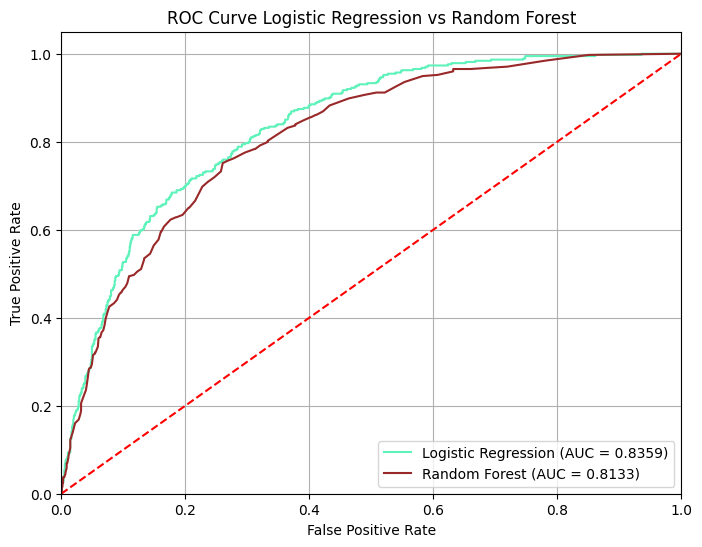

In [259]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay


def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label='Yes')
    roc_auc = auc(fpr, tpr)
    print(f"{model_name} AUC: {roc_auc:.4f}")
    
    plt.plot(fpr, tpr, color=np.random.rand(3,), label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.figure(figsize=(8, 6))
plot_roc_curve(y_test, y_prob_lr[:, 1], 'Logistic Regression')
plot_roc_curve(y_test, y_prob_rf[:, 1], 'Random Forest')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve Logistic Regression vs Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

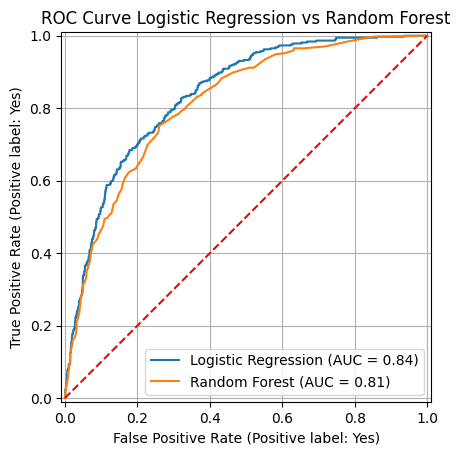

In [260]:
lr_roc_curve=RocCurveDisplay.from_estimator(model1, X_test_processed, y_test, pos_label='Yes', name='Logistic Regression')
rf_roc_curve=RocCurveDisplay.from_estimator(model2, X_test_processed, y_test, pos_label='Yes', name='Random Forest', ax=lr_roc_curve.ax_)

plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve Logistic Regression vs Random Forest')
plt.grid()
plt.show()

## Challenge 12: Business Summary Report

**Goal:** Communicate findings to non-technical stakeholders.

**Steps:**
1. Write markdown report with sections:
   - **Problem:** What are we solving? Why?
   - **Data:** How many customers? What features?
   - **Model:** Which model? Why?
   - **Results:** Accuracy, precision, recall (in plain English)
   - **Key Findings:** Top 3-5 churn drivers
   - **Recommendation:** What should the company do?
   - **Limitations:** What we don't know?

2. Use business language (no jargon)
3. Include 1-2 key charts

**Example structure:**
```
# Churn Prediction Report

## Executive Summary
We built a model to predict which customers will leave us.
The model is 85% accurate and can identify 70% of at-risk customers.

## Key Findings
1. Contract type matters most
2. High monthly charges correlate with churn
3. Longer tenure = more loyal

## Recommendations
- Offer discounts to high-value customers
- Improve onboarding for new customers
```

# Customer Churn Prediction Report

1. Problem

The goal of this project was to understand why customers are terminating their service (churning) and to build a model that can predict which customers are at risk of leaving.

This is important for businesses because identifying at-risk customers early allows them to take action and improve retention.

2. Data

The dataset contained over 7,000 customers with a mix of:

Demographic features: gender, partner, dependents
Service features: internet service, tech support, online security, streaming services
Account features: contract type, payment method
Numerical features: tenure, monthly charges, total charges

The target variable was Churn (Yes/No).

3. Data Exploration & Insights

Before modeling, I explored the data using visualizations.

Key observations:
Most customers do not churn, but there is a meaningful minority that does.
Customers on month-to-month contracts churn significantly more than those on long-term contracts.
Customers using automatic payments (bank transfer, credit card) are less likely to churn.
Customers without tech support or security services show higher churn rates.

These insights helped guide expectations before modeling.

4. Models Used

Since this is a binary classification problem, I tested two models:

Logistic Regression (simple, linear baseline)
Random Forest Classifier (more complex, non-linear model)

Initially, I expected Random Forest to perform better due to its ability to capture complex relationships.

5. Model Performance
Logistic Regression:
Accuracy: 0.8038
Precision: 0.6485
Recall: 0.5722
F1 Score: 0.6080
AUC: 0.8359
Random Forest:
Accuracy: 0.7832
Precision: 0.6194
Recall: 0.4786
F1 Score: 0.5400
AUC: 0.8133

Conclusion:

Logistic Regression outperformed Random Forest across all metrics.

This suggests that the dataset likely follows relatively linear patterns, making a simpler model more effective.

6. Confusion Matrix Insights (Logistic Regression)
True Negatives: 917
False Positives: 116
False Negatives: 160
True Positives: 214
Interpretation:
The model performs well at identifying customers who will not churn.
However, it misses 160 churners, meaning some at-risk customers are not detected.
Recall (~57%) shows the model catches just over half of actual churners.

 This indicates room for improvement, especially in capturing more churners.

7. Key Drivers of Churn (Feature Importance)

Top factors influencing churn:

TotalCharges
Tenure
MonthlyCharges
Month-to-month contracts
No OnlineSecurity
Electronic check payments
Fiber optic service
No TechSupport
Insights:
Customers with short tenure and high monthly costs are more likely to churn.
Lack of commitment (month-to-month contracts) strongly increases churn risk.
Customers without support or security services are more likely to leave.
Payment behavior reflects stability — manual payments correlate with higher churn.
8. Business Recommendations

Based on the analysis:

1. Encourage long-term contracts
Offer discounts or incentives for annual plans
Reduce churn from month-to-month customers
2. Improve early customer experience
Focus on onboarding new customers
Early-stage churn is high
3. Promote support and security services
Bundle tech support or security features
Increase perceived value
4. Optimize pricing strategy
High monthly charges correlate with churn
Consider loyalty discounts or pricing adjustments
5. Encourage automatic payments
Incentivize bank/credit auto-pay
Reduce churn from manual payment users
9. Limitations
Recall is moderate (~57%), meaning some churners are still missed
No hyperparameter tuning was performed
No feature engineering beyond basic preprocessing
External factors (customer satisfaction, competitors, etc.) are not included
10. Final Conclusion

Logistic Regression proved to be the most effective model for this dataset, achieving strong performance across all evaluation metrics.

Churn is primarily driven by:

Lack of commitment
High cost
Limited service/support
Early-stage customers



## Tuning Learning Checkpoint

### What tuning means in this project
In this churn project, tuning means changing model settings or the decision threshold **after** you have a working baseline and then checking whether the change improves the metric that matters.

### What you should tune first
- Start with a simple baseline such as Logistic Regression.
- Tune the **threshold** first if your model is missing too many churners.
- Tune `class_weight`, `C`, `max_depth`, or `n_estimators` only after you understand the current error pattern.

### What not to do
- Do not use the test set over and over to pick settings.
- Do not change preprocessing, features, model type, and threshold all at once.
- Do not optimize accuracy if recall or F1 better matches the retention goal.

### Questions to answer in this notebook
1. What baseline did I start with?
2. Which tuning change did I try first, and why?
3. Did tuning improve recall, precision, or F1 in the way I wanted?
4. What tradeoff got worse when the tuned score improved?

See also: `docs/HYPERPARAMETER_TUNING_GUIDE.md` and `docs/QUICK_REFERENCE.md`.

## Tuning Report Template

Use this version for churn or other tabular classification work.

```text
Tuning target: improve churn detection quality
Baseline model:
Baseline recall / precision / F1:

Failure mode I was trying to improve:
- missing likely churners
- too many false positives
- weak performance on a specific customer segment

Setting(s) tuned:
- threshold
- class_weight
- C / max_depth / n_estimators / min_samples_leaf

Why I chose these first:

Validation method used:
Metric optimized:

Best setting found:
Best validation result:

What improved:
What got worse:
Segment or slice still weak:

Final test result:
Business tradeoff accepted:
Next tuning step:
```

## Improve This: Churn Tuning Report Challenge

Build your own report from your real notebook results. Do not copy a canned answer.

### Your challenge
Write a complete tuning report using your own numbers and observations.

### Minimum requirements
1. State your baseline model and baseline metrics.
2. Name the first failure mode you targeted.
3. Explain why you tuned the first setting (threshold, class weight, or model hyperparameter).
4. Show the before vs after metric change.
5. Describe one tradeoff that got worse.
6. Identify one weak customer slice that still needs improvement.
7. Propose your next tuning step and why.

### Self-check rubric
- Clear baseline and tuned comparison
- Metric choice matches churn business goal
- Tradeoff is explicitly discussed
- Next step is specific and testable

### Submit format
Use the Tuning Report Template in the cell above and fill every field with your own evidence.

Tip: your report is strong only if another person can reproduce your reasoning from your notes and metrics.

In [261]:
from sklearn.model_selection import GridSearchCV


gridSearch_params = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear', 'lbfgs']
}

In [262]:
lr_grid_model=GridSearchCV(
    estimator=model1, 
    param_grid=gridSearch_params, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1
     )

lr_grid_model.fit(X_train_processed, y_train)

/Users/jjcatulle/Desktop/ML-AI-learning/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/jjcatulle/Desktop/ML-AI-learning/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/jjcatulle/Desktop/ML-AI-learning/.venv/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/Users/jjcatulle/Desktop/ML-AI-learning/.venv/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/Users/jjcatulle/Desktop/ML-AI-learning/.venv/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    resul

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='recall')

In [263]:

from sklearn.metrics import make_scorer, f1_score, recall_score


recall_yes = make_scorer(recall_score, pos_label='Yes')

lr_grid_model = GridSearchCV(
    estimator=model1,
    param_grid=gridSearch_params,
    cv=5,
    scoring=recall_yes,
    n_jobs=-1
)

lr_grid_model.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring=make_scorer(recall_score, response_method='predict', pos_label=Yes))

In [264]:
print("Best params:", lr_grid_model.best_params_)
print("Best CV score:", lr_grid_model.best_score_)

Best params: {'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV score: 0.8046822742474916


In [265]:
grid_model_preds=lr_grid_model.predict(X_test_processed)
lr_grid_model.score(X_test_processed, y_test)

0.7967914438502673

In [267]:
grid_cr=classification_report(y_test, grid_model_preds)
print("Grid Search Logistic Regression Classification Report:\n", grid_cr)

Grid Search Logistic Regression Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



<Axes: >

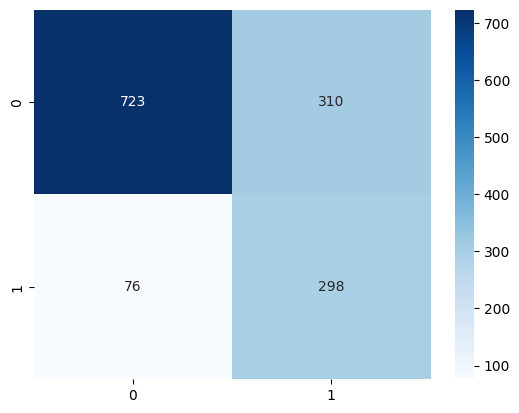

In [266]:
sns.heatmap(confusion_matrix(y_test, grid_model_preds), annot=True, fmt='d', cmap='Blues')

## Tuning Report

Before tuning, my primary focus was improving the recall score, which was initially **0.57**.

This was my main target because a higher recall means the model can correctly identify more customers who are likely to churn. In a business context, missing a churner is more costly than incorrectly flagging a customer who will stay.

After applying Grid Search tuning, the recall score improved significantly from **0.57 to 0.80**. This shows that the model became much better at detecting customers at risk of leaving.

However, this improvement came with tradeoffs. Precision decreased from **0.65 to 0.49**, and overall accuracy dropped from **0.80 to 0.73**. This means the model is now more aggressive and produces more false positives.

Even though the model became less precise and slightly less accurate, it better fulfills its primary goal of identifying churners. From a business perspective, this tradeoff is acceptable because it is more important to catch potential churners than to avoid false alarms.

For the next step, I plan to improve the balance between recall and precision. I can do this by tuning the decision threshold and experimenting with additional model parameters or feature engineering to improve overall performance without sacrificing too much recall.
